# **Maestría en Inteligencia Artificial Aplicada (MNA)**
## **Procesamiento de Lenguaje Natural (NLP)**
### Prof. Luis Eduardo Falcón Morales
### **Semanas 6 y 7 - Ejercicios Complementarios**
### Modelado de Temas: LSI / LDA.

### **NOTA: Estos ejercicios son simplemente para que repases los conceptos de esta semana.**
### **No es una tarea o actividad que debas entregar.**

## 🗺️ Mapa del Notebook — Qué hace cada parte

Este notebook explora **Modelado de Temas (Topic Modeling)**: descubrir automáticamente los temas ocultos en una colección de documentos sin etiquetas previas. Se trabajan tres enfoques progresivos:

| Parte | Técnica | Herramienta | Qué resuelve |
|-------|---------|-------------|--------------|
| **1** | LSI manual | sklearn | TF-IDF + SVD Truncada paso a paso |
| **2** | LSI con librería | Gensim LsiModel | Misma idea, más eficiente + coherencia |
| **3** | LDA | Gensim LdaModel | Enfoque probabilístico, más interpretable |
| **4** | Predicción | LDA entrenado | Clasificar documentos nuevos sin reentrenar |
| **5** | Coherencia | CoherenceModel | Elegir el número óptimo de temas (k) |
| **6** | N-gramas | Gensim Phrases | Detectar bigramas/trigramas automáticamente |

**Flujo lógico:**
```
Docs tokenizados
    → TF-IDF o BOW        (representación numérica)
    → LSI (SVD) o LDA     (descubrir temas)
    → Coherencia          (validar cuántos temas usar)
    → Predicción          (usar el modelo con texto nuevo)
    → N-gramas            (enriquecer tokens antes de modelar)
```

---

## 🔑 Conceptos clave

| Concepto | Qué es | Para qué sirve aquí |
|----------|--------|---------------------|
| **TF-IDF** | Peso de palabra en documento | Entrada numérica a LSI |
| **SVD Truncada** | Descomposición matricial con r componentes | Extrae temas latentes en LSI |
| **Valores singulares (Σ)** | Importancia de cada tema, ordenados de mayor a menor | Decidir cuántos temas conservar |
| **Matriz term-topic** | Palabras × temas (filas=palabras, cols=temas) | Identificar qué palabras definen cada tema |
| **BOW** | Tuplas (id_palabra, frecuencia) | Formato de entrada para Gensim |
| **alpha / eta** | Hiperparámetros LDA | Controlan pureza de temas y documentos |
| **Coherencia c_v** | Métrica de calidad de temas | Elegir k óptimo sin etiquetas |
| **Bigramas** | Pares de palabras frecuentes fusionados | Preservar significado compuesto |

---

## 💼 Casos de uso de negocio

| Industria | Problema real | Cómo aplica este notebook |
|-----------|---------------|--------------------------|
| **Banca / Fintech** | Clasificar miles de quejas de clientes automáticamente | LDA agrupa tickets por tema: fraude, app, cobros |
| **E-commerce** | Analizar reseñas de productos sin leerlas | LSI detecta temas: calidad, envío, precio |
| **Legal** | Organizar expedientes o contratos por tipo | LDA encuentra temas: laboral, civil, penal |
| **Salud** | Clasificar notas médicas o registros de pacientes | LSI agrupa por síntoma, diagnóstico, medicamento |
| **Medios** | Detectar temas emergentes en noticias en tiempo real | Coherencia + LDA con corpus dinámico |
| **RH** | Analizar comentarios de empleados en encuestas | LDA revela temas: liderazgo, salario, cultura |

---

## ⚠️ Advertencias técnicas (leer antes de usar en producción)

**Sesgos presentes:**
- El corpus de ejemplo (6 docs, 14 palabras) es demasiado pequeño — los resultados son ilustrativos, no representativos.
- Con tan pocos documentos, la coherencia no es confiable como métrica de selección de k.
- LSI no da probabilidades reales — los signos negativos dificultan la interpretación directa.

**¿Cumplimos el objetivo?**
- ✅ LSI y LDA encuentran los 3 temas reales (frutas, cocina, literatura) con corpus pequeño.
- ⚠️ La coherencia no selecciona consistentemente k=3 como óptimo en este ejemplo.
- ✅ La predicción de documento nuevo funciona correctamente con LDA.

**Escalabilidad a producción:**
- Corpus real (>10k docs): usar `LdaMulticore` en lugar de `LdaModel`.
- Vocabularios grandes (>50k palabras): SVD Truncada sigue siendo viable; LDA puede requerir más `passes`.
- Los modelos entrenados se guardan con `model.save('modelo.lda')` y se recargan con `LdaModel.load(...)`.
- En producción se recalcula coherencia periódicamente para detectar drift temático.

# Parte - 1: 

## Indexación Semántica Latente - LSI - Latent Semantic Indexing

## ⚠️ Error frecuente al instalar: `--user` en entornos conda

El notebook original usa `!pip install ... --upgrade --user`. Esto **falla silenciosamente** en conda:
- `--user` instala en `~/.local/lib/pythonX.X/site-packages/`
- El kernel de Jupyter dentro de un entorno conda **no busca en esa carpeta**
- Resultado: la instalación "funciona" pero el `import` lanza `ModuleNotFoundError`

**Solución correcta:** usar `{sys.executable}` para garantizar que pip instala exactamente en el Python del kernel activo:
```python
import sys
!{sys.executable} -m pip install gensim --upgrade
```

Librerías requeridas:
- **scipy**: álgebra lineal y estadística; TruncatedSVD la usa internamente.
- **gensim**: librería especializada en LSI, LDA, Word2Vec, etc.
- **numpy**: operaciones vectoriales; base de todo el ecosistema ML.

In [1]:
import sys
!{sys.executable} -m pip install scipy --upgrade

In [2]:
import sys
!{sys.executable} -m pip install gensim --upgrade

In [3]:
import sys
!{sys.executable} -m pip install numpy --upgrade

## 📦 Librerías que usaremos
| Librería | Para qué |
|----------|----------|
| `pandas` | Visualizar matrices como tablas |
| `seaborn` / `matplotlib` | Gráficas de barras de importancia de temas |
| `gensim` | LSI y LDA nativos, diccionario y BOW |
| `TfidfVectorizer` | Convertir texto a matriz TF-IDF (sklearn) |
| `TruncatedSVD` | Factorización SVD truncada para LSI (sklearn) |

In [4]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

import gensim
import gensim.corpora as corpora

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

Supongamos que iniciamos con los documentos ya tokenizados, después de la limpieza y procesado de los documentos de la manera usual en la que hemos venido procediendo:

## 📄 El corpus de ejemplo
6 documentos ya tokenizados (palabras separadas en listas). Se asume que ya pasaron por limpieza previa (eliminación de stopwords, lematización, etc.).

Visualmente existen **3 temas reales**:
- Docs 0-1 → **Frutas** (manzana, pera, uva, melón, sandía)
- Docs 2-4 → **Cocina** (estufa, olla, horno, cuchara)
- Doc 5   → **Literatura** (libro, autor, novela, ficción)

El objetivo: que el algoritmo los descubra **solo**, sin etiquetas.

In [156]:
docs = [['manzana','manzana','pera', 'pera','uva','uva','melon','sandia'],
        ['manzana','manzana','manzana','uva','uva','melon','melon','cocina',],
        ['estufa','estufa','estufa','olla','olla','olla','horno','horno'],
        ['horno','horno','horno','cuchara','cuchara','olla','uva','uva'],
        ['horno','manzana','pera','pera','olla','olla'],
        ['libro','libro','autor','novela','novela','ficcion']
        ]

docs

[['manzana', 'manzana', 'pera', 'pera', 'uva', 'uva', 'melon', 'sandia'],
 ['manzana', 'manzana', 'manzana', 'uva', 'uva', 'melon', 'melon', 'cocina'],
 ['estufa', 'estufa', 'estufa', 'olla', 'olla', 'olla', 'horno', 'horno'],
 ['horno', 'horno', 'horno', 'cuchara', 'cuchara', 'olla', 'uva', 'uva'],
 ['horno', 'manzana', 'pera', 'pera', 'olla', 'olla'],
 ['libro', 'libro', 'autor', 'novela', 'novela', 'ficcion']]

## 🔗 Convertir listas a strings
`TfidfVectorizer` de sklearn espera **strings**, no listas de tokens. Por eso reunimos cada lista con espacios:
`['manzana','pera'] → 'manzana pera'`
Esta conversión es solo un paso de formato; no pierde información porque el vectorizador vuelve a separar por espacios.

In [82]:
# Conjuntamos los documentos de nuevo en una lista de strings,
# que viene a ser nuestra document-term-matrix, DTM:

ddf = []

for doc in docs:
    tmp = ' '.join(doc)
    ddf.append(tmp)
    
ddf

['manzana manzana pera pera uva uva melon sandia',
 'manzana manzana manzana uva uva melon melon cocina',
 'estufa estufa estufa olla olla olla horno horno',
 'horno horno horno cuchara cuchara olla uva uva',
 'horno manzana pera pera olla olla',
 'libro libro autor novela novela ficcion']

In [83]:
ddf[0]

'manzana manzana pera pera uva uva melon sandia'

### Obtengamos la matriz Tf-idf a partir de los documentos ya procesados:

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

## 📊 Matriz TF-IDF — el punto de partida numérico
TF-IDF convierte texto a números que el modelo puede procesar.

- **TF (Term Frequency)**: qué tan frecuente es la palabra *en ese documento* (normalizado).
- **IDF (Inverse Document Frequency)**: penaliza palabras que aparecen en *todos* los documentos (son poco informativas).

Resultado: matriz dispersa (sparse) **6 documentos × 14 palabras**. La mayoría de celdas son 0 porque cada documento solo contiene algunas palabras del vocabulario total.

Parámetros usados:
- `max_df=1.0` → no ignora ninguna palabra por frecuencia máxima.
- `min_df=1` → incluye hasta palabras que aparecen en un solo documento.

## 🎛️ Parámetros ajustables — TfidfVectorizer

| Parámetro | Valor actual | Cuándo cambiarlo |
|-----------|-------------|------------------|
| `lowercase=True` | Sí | Déjalo en True salvo que mayúsculas tengan significado (ej. siglas) |
| `max_df=1.0` | Sin límite superior | Bájalo (ej. `0.85`) para ignorar palabras que aparecen en >85% de docs — suelen ser stopwords no capturadas |
| `min_df=1` | Incluye todo | Súbelo (ej. `5`) en corpus grandes para ignorar palabras rarísimas que probablemente son ruido |

📥 **Datos de entrada:** `ddf` — la lista de strings generada en la celda anterior a partir de `docs`.

In [84]:
tfidf = TfidfVectorizer(lowercase=True, # puedes incluir algunas transformaciones, en caso de que no las hayas llevado a cabo previamente.
                        max_df=1.0,  # (float o int) ignora las palabras con frecuencia mayor a max_df
                        min_df=1     # ignora las palabras con frecuencia menor a min_df
                       )

tfidf_sparse = tfidf.fit_transform(ddf)     # csr_matrix de la DTM

## 👁️ Visualizar la Matriz TF-IDF (solo para exploración)

**Orientación de esta matriz:**
- **Filas** = documentos (doc 0, doc 1, ...)
- **Columnas** = palabras del vocabulario (autor, cocina, estufa...)
- **Valores** = peso TF-IDF de cada palabra en cada documento

⚠️ **Esta NO es la misma matriz que verás más adelante (term-topic).** Son dos matrices distintas:
| Matriz | Filas | Columnas | Cuándo aparece |
|--------|-------|----------|----------------|
| **TF-IDF** (`tfidf_dense`) | Documentos | Palabras | Aquí, se borra después |
| **Term-topic** (`term_topic_matrix`) | Palabras | Temas | Después del SVD |

`.toarray()` convierte la matriz dispersa a densa para poder verla. **Nunca hagas esto con datasets grandes** — consume memoria proporcional a documentos × palabras.

In [85]:
# Este paso no es necesario, solo utilízalo si deseas visualizar la matriz dispersa de 
# manera estándar... pero no es recomendable con conjunto de datos muy grandes:

tfidf_dense = pd.DataFrame(tfidf_sparse.toarray(), columns=tfidf.get_feature_names_out()) 

tfidf_dense.head()

,autor,cocina,cuchara,estufa,ficcion,horno,libro,manzana,melon,novela,olla,pera,sandia,uva
0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.483636,0.286423,0.0,0.000000,0.572845,0.34929,0.483636
1,0.0,0.317492,0.000000,0.000000,0.0,0.000000,0.0,0.659410,0.520695,0.0,0.000000,0.000000,0.00000,0.439607
2,0.0,0.000000,0.000000,0.768704,0.0,0.354789,0.0,0.000000,0.000000,0.0,0.532183,0.000000,0.00000,0.000000
3,0.0,0.000000,0.611128,0.000000,0.0,0.634637,0.0,0.000000,0.000000,0.0,0.211546,0.000000,0.00000,0.423092
4,0.0,0.000000,0.000000,0.000000,0.0,0.293461,0.0,0.293461,0.000000,0.0,0.586923,0.695185,0.00000,0.000000


## 🗑️ Liberar memoria
La matriz densa ya no se necesita para los siguientes pasos; el modelo trabaja sobre la dispersa `tfidf_sparse`. Borrarla libera RAM.

In [86]:
# después de visualizarla la puedes borrar, ya que no se requiere para lo que sigue,
# y sobre todo cuando sea algo grande dicha matri:

del tfidf_dense

# Procedamos con la factorización SVD:

### No es necesario realizar la factorización completa ya que sabemos que solamente estaremos tomando un subconjunto de los valores singulares más grandes y que estarán relacionados a la cantidad de tópicos a encontrar.

### Por ello es suficiente con utilizar la factorización truncada de SVD:

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html 

## 🧮 SVD Truncada — el corazón de LSI

SVD descompone la matriz TF-IDF `A` en tres matrices:

> **A = U × Σ × Vᵀ**

| Matriz | Dimensión | Significado |
|--------|-----------|-------------|
| **U** | docs × r | Relación documentos → temas |
| **Σ** | r valores | Importancia de cada tema (ordenados de mayor a menor) |
| **Vᵀ** | r × palabras | Relación temas → palabras |

**¿Qué significa truncar?** La SVD completa calcula todos los componentes posibles (hasta min(docs, palabras)). Los últimos componentes capturan variaciones mínimas = ruido. Con `r=3` nos quedamos solo con los 3 más informativos:

```
Valores singulares completos: [1.48, 1.15, 1.00, 0.12, 0.04, 0.01]
Truncados con r=3:             [1.48, 1.15, 1.00]  ← solo estos
                                                    ← los 3 últimos se descartan
```

**La truncación elimina COLUMNAS (temas), nunca filas (palabras).** Todas las palabras del vocabulario siempre están presentes en la matriz resultante.

## 🎛️ Parámetros ajustables — SVD Truncada (r = número de temas)

| Parámetro | Valor actual | Cuándo cambiarlo |
|-----------|-------------|------------------|
| `r = 3` | 3 temas | El parámetro más importante. Cambia según cuántos temas esperas en tu corpus. Aquí sabemos que hay 3 (frutas, cocina, literatura) |
| `n_iter=100` | 100 iteraciones | Bájalo a 10-20 si el corpus es grande y el tiempo importa. Súbelo si los valores singulares no convergen |
| `random_state=42` | Fijo | Cámbialo solo si quieres explorar variabilidad. Fijarlo garantiza resultados reproducibles |

⚠️ **Criterio para elegir r:** grafica los valores singulares y busca el "codo" donde la curva deja de caer rápido. En producción usa la métrica de Coherencia (Parte 2 y 5).

📥 **Datos de entrada:** `tfidf_sparse` — la matriz TF-IDF dispersa calculada arriba.

In [87]:
# Se define el objeto que aplicará SVD truncada con r valores singulares:

r = 3    # Máxima cantidad de valores singulares a considerar --> tópicos a generar:

lsi_obj = TruncatedSVD(n_components = r, 
                       n_iter=100,  # número de iteraciones ... recordemos que es un método iterativo.
                       random_state=42) 

tfidf_lsi = lsi_obj.fit_transform(tfidf_sparse)    # ndarray: se ajusta y aplica la SVD truncada.


Sigma = lsi_obj.singular_values_     # ndarray_(r,)

V_T = lsi_obj.components_.T         # ndarray_(n_terms X r)  
                                    # Las r columnas son los r temas/topics generados
                                    # Se ordenan los n_terms/words de mayor a menor para 
                                    # obtener las keywords principales de cada tópico.

## 📈 Valores singulares — importancia relativa de cada tema
Cada valor en `Sigma` indica cuánta varianza del corpus captura ese componente latente. El componente 0 (mayor valor) captura más información que el componente 2 (menor valor). La gráfica de barras hace esto visible.

In [88]:
sigmas = lsi_obj.singular_values_

sigmas

array([1.48448256, 1.15394397, 1.        ])

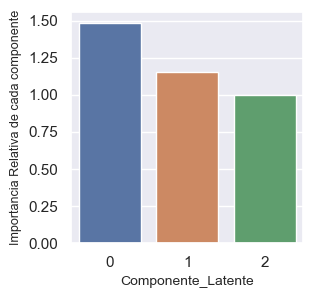

In [89]:
sns.set(rc={'figure.figsize':(3,3)}) 
chart = sns.barplot(x=list(range(len(Sigma))), y = Sigma )
chart.set_xlabel('Componente_Latente', fontdict={'size': 10})
chart.set_ylabel('Importancia Relativa de cada componente', fontdict={'size': 9})
plt.show()

## 🗂️ Matriz term-topic — orientación opuesta a TF-IDF

**Orientación de esta matriz (opuesta a la TF-IDF):**
- **Filas** = palabras del vocabulario
- **Columnas** = temas (Concepto_Latente_0, 1, 2)

⚠️ **Nombre confuso en el código:**
```python
V_T = lsi_obj.components_.T
```
- `components_` tiene shape **(r × palabras)** → eso es Vᵀ
- `.T` la transpone a **(palabras × r)** → eso es V
- La variable se llama `V_T` pero en realidad es **V** (ya transpuesta). El nombre es engañoso.

**Qué significan los valores ≈0:**
Si una palabra tiene peso ≈0 en un tema, **no significa que se descarte** — significa que esa palabra no define ese tema. Ejemplo: `novela ≈ 0` en Concepto_0 (cocina/frutas) es correcto y esperado.

In [90]:
# La matriz V-transpuesta es la que genera la relación Terms(word)-Topics,
# los renglones son los términos/words y las columnas los tópicos/temas:

lsi_term_topic = V_T 

print(lsi_term_topic.shape)

(14, 3)


In [91]:
# rescatemos los nombres de los términos/tokens:

term_names = list(tfidf.get_feature_names_out())

print(term_names)

['autor', 'cocina', 'cuchara', 'estufa', 'ficcion', 'horno', 'libro', 'manzana', 'melon', 'novela', 'olla', 'pera', 'sandia', 'uva']


## 🏷️ DataFrame term-topic — palabras × temas

El DataFrame tiene **palabras como filas** y **temas como columnas**. Es la orientación inversa a la matriz TF-IDF que vimos antes:

```
TF-IDF:      filas=documentos,  columnas=palabras  → entrada al SVD
term-topic:  filas=palabras,    columnas=temas     → salida del SVD
```

Los valores ≈0 en la tabla (como los de `novela` en Concepto_0 y Concepto_1) **no son ruido que se corta** — son información válida que dice: *"novela no pertenece a esos temas"*.

In [92]:
# Y generamos un DataFrame con la matriz term-topic:

term_topic_matrix = pd.DataFrame(data=lsi_term_topic, 
                                 index = term_names,   
                                 columns = [f'Concepto_Latente_{r}' for r in range(0,V_T.shape[1])]
                                )

print(term_topic_matrix.shape)   #  words X topics

(14, 3)


Cada columna será un tópico (topic/Latent-Concept), donde se indican los pesos de cada palabra (term)
que define dicho tópico, a través de las palabras con los mayores pesos:

In [93]:
#term_topic_matrix.head()    # Cuando es muy grande el DataFrame, mejor visualizarlo con head().

term_topic_matrix   # los renglones son los terms/words 
                    # y las columnas los conceptos latentes o tópicos:

,Concepto_Latente_0,Concepto_Latente_1,Concepto_Latente_2
autor,-1.561058e-17,-9.495402e-17,3.162278e-01
cocina,9.698820e-02,-1.328444e-01,3.465990e-16
cuchara,1.551490e-01,1.911549e-01,-1.975179e-15
estufa,1.472567e-01,4.349324e-01,1.735115e-15
ficcion,-1.561058e-17,-1.210803e-16,3.162278e-01
horno,3.311435e-01,4.570066e-01,-1.208919e-15
libro,-3.122116e-17,-2.421607e-16,6.324555e-01
manzana,4.833982e-01,-3.851308e-01,7.471785e-16
melon,2.656046e-01,-3.167591e-01,4.786493e-16
novela,-3.122116e-17,-2.421607e-16,6.324555e-01


## 🔍 Interpretar un Concepto Latente

Para identificar el tema de un Concepto Latente se ordenan las palabras de mayor a menor peso y se visualizan las top-N.

**Regla para leer la tabla:**
- Peso **alto** en un tema → la palabra define ese tema
- Peso **≈0** en un tema → la palabra no pertenece a ese tema (no se corta, es información)
- Peso **negativo** (solo en LSI) → la palabra va en dirección contraria al tema

Ejemplo del Concepto_Latente_2:
```
novela  → 0.63  ← define este tema ✅
libro   → 0.63  ← define este tema ✅
horno   → ≈0   ← no pertenece aquí (correcto, es cocina)
manzana → ≈0   ← no pertenece aquí (correcto, es fruta)
```

Este paso de **etiquetar** el tema ("Literatura", "Cocina", "Frutas") siempre es **manual** — el algoritmo solo revela los pesos, no los nombres.

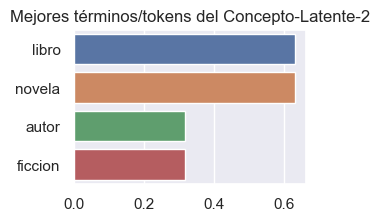

In [94]:
# Seleccionemos por ejemplo una de las columnas/tópico "Concepto_Latente":

data = term_topic_matrix[f'Concepto_Latente_2']

# ordenamos lo valores singulares de la columna/tópico de manera descendente.
data = data.sort_values(ascending=False) # Con la opción True, visualizarás los de menor peso.    

top_w = 4      # Define la cantidad de las mejores "top_w" términos/words a visualizar.
top_w_matrix = data[:top_w]    # Nos quedamos con los mejores top_w pesos, asociados a 
                               # los top_w terms (words).

sns.set(rc={'figure.figsize':(3,2)}) 
plt.title('Mejores términos/tokens del Concepto-Latente-2')
fig = sns.barplot(x= top_w_matrix.values, y=top_w_matrix.index)

Rápidamente observamos que el concepto latente asociado a estos terms sería en relación a un tema sobre autores de novelas, en paticular de ficción.

Puedes llevar a cabo la visualización de los Conceptos-Latentes restantes para determinar cuales podrían ser dichas temáticas.

Trata de determinar cómo podrías describir al resto de los tópicos, en relación a sus términos/words de mayor peso.

Podrías también hacerlo mediante nube de palabras.

Recuerda que no hay una solución única.

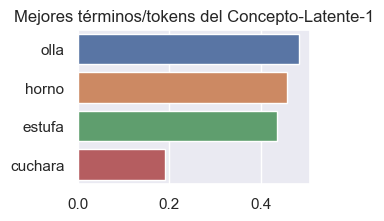

In [95]:
# Otro de los conceptos latentes es el siguiente:

data = term_topic_matrix[f'Concepto_Latente_1']

# ordenamos lo valores singulares de la columna/tópico de manera descendente.
data = data.sort_values(ascending=False) # Con la opción True, visualizarás los de menor peso.    

top_w = 4      # Define la cantidad de las mejores "top_w" términos/words a visualizar.
top_w_matrix = data[:top_w]    # Nos quedamos con los mejores top_w pesos, asociados a 
                               # los top_w terms (words).

sns.set(rc={'figure.figsize':(3,2)}) 
plt.title('Mejores términos/tokens del Concepto-Latente-1')
fig = sns.barplot(x= top_w_matrix.values, y=top_w_matrix.index)

¿Qué nombre le pondrías a esta temática?

Podrías además agregar una función que facilite la visualización de estos conceptos latentes.

# Parte - 2: LSI con Gensim


Obviamente existen funciones que implementan la SVD truncada de manera directa.

Estos métodos se basan en algoritmos iterativos que facilitan la obtención de dicha factorización, sobre todo con matrices de gran dimensión.

En esta actividad usaremos en particular la librería de Gensim. 

Revisa la documentción correspondiente para mayor detalle y veamos lo que obtenemos.

Además, aprovecharemos para evaluar la cantidad de tópicos generados mediante la métrica de Coherencia. Recuerda que LSI es una técnica no supervisada y no conocemos de antemano la cantidad de tópicos en nuestro corpus.

https://radimrehurek.com/gensim/models/lsimodel.html 

https://radimrehurek.com/gensim/models/coherencemodel.html

## 🔄 Parte 2 — LSI con Gensim
Gensim implementa LSI directamente con `LsiModel`. Ventajas sobre sklearn:
- Maneja corpora muy grandes (procesamiento por chunks).
- Incluye herramientas para evaluar la calidad de los temas (Coherencia).
- Trabaja directamente con BOW sin necesitar TF-IDF explícito.

Se importa también `CoherenceModel` para encontrar el número óptimo de temas.

In [96]:
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel

En este caso partimos de la lista de listas con los documentos tokenizados:

## 📖 Dictionary y Bag-of-Words (BOW)
**Dictionary**: mapea cada palabra única a un ID numérico. Ejemplo: `{manzana: 0, pera: 1, uva: 2, ...}`

**BOW (Bag of Words)**: representa cada documento como lista de tuplas `(id_palabra, frecuencia)`.
Ejemplo: `doc_0 = [(0,2), (1,2), (4,2), ...]` → manzana×2, pera×2, uva×2...

BOW **pierde el orden** de las palabras, pero es compacto y suficiente para modelado de temas.

## 📥 Datos de entrada — Parte 2 (Gensim LSI)

Esta parte **retoma exactamente `docs`** — la lista de listas definida al inicio del notebook:
```python
docs = [['manzana','pera',...], ['estufa','olla',...], ...]
```

No usa la matriz TF-IDF de la Parte 1. Gensim construye su propia representación interna (BOW) a partir de los tokens originales. Ambos enfoques parten del mismo corpus pero lo procesan de forma independiente.

In [149]:
mi_dicc = corpora.Dictionary(docs)     # generamos el diccionario

bow = [mi_dicc.doc2bow(doc) for doc in docs]   # y luego la BOW

## 🔁 Búsqueda del número óptimo de temas con Coherencia
Como LSI es **no supervisado**, no sabemos cuántos temas existen en el corpus. Entrenamos un modelo para cada valor de `k` (de 2 a 8) y medimos la **coherencia**:

- `coherence='c_v'`: variante que mide co-ocurrencia de palabras en ventanas de texto.
- `topn=3`: solo evalúa las 3 palabras principales de cada tema.
- `window_size=3`: ventana de 3 palabras alrededor de cada término.

**Regla:** mayor coherencia = temas más semánticamente consistentes.

## 🎛️ Parámetros ajustables — Búsqueda de k óptimo

| Parámetro | Valor actual | Cuándo cambiarlo |
|-----------|-------------|------------------|
| `range(2, 9)` | Prueba k=2 a k=8 | Amplía el rango si sospechas más temas. Empieza siempre desde 2 |
| `chunksize=6` | 6 docs por lote | Iguálalo al tamaño del corpus si es pequeño. En corpus grandes usa 1000-2000 |
| `window_size=3` | Ventana de 3 palabras | `c_v` recomienda 110; aquí está bajo por corpus pequeño |
| `coherence='c_v'` | Métrica c_v | Usa `c_umass` si no tienes acceso al corpus de referencia externo |
| `topn=3` | Top 3 palabras por tema | Súbelo a 10 en corpus grandes para evaluación más robusta |

📥 **Datos de entrada:** `bow` (BOW de Gensim) + `docs` (tokens originales para coherencia) + `mi_dicc` (diccionario).

In [169]:
for i in range(2,9):
    
    lsi = LsiModel(bow, 
                   num_topics=i, 
                   id2word=mi_dicc,
                   chunksize=6,
                   random_seed=7
                  )     
    
    cm = CoherenceModel(model=lsi, 
                        texts=docs, 
                        dictionary=mi_dicc, 
                        window_size=3,
                        coherence='c_v',
                        topn = 3
                       )
    
    cs = cm.get_coherence()
    
    print('Métrica de Coherencia con {} clusters: {}'.format(i, cs))

Métrica de Coherencia con 2 clusters: 0.2491406350758302
Métrica de Coherencia con 3 clusters: 0.25026891639723087
Métrica de Coherencia con 4 clusters: 0.24033388941780415
Métrica de Coherencia con 5 clusters: 0.23608410439864005
Métrica de Coherencia con 6 clusters: 0.24387557991244402
Métrica de Coherencia con 7 clusters: 0.25158729178298195
Métrica de Coherencia con 8 clusters: 0.32070071519773896


## ✅ Modelo final LSI con k=3
Se elige `num_topics=3` (el más interpretable para este corpus). `lsi.print_topics(num_words=4)` muestra las 4 palabras con mayor peso por tema.

Los **signos negativos** son normales en LSI: indican que la palabra va en dirección opuesta al componente latente. Con corpus pequeños esto es más común.

In [174]:
# Seleccionas el mejor de los anteriores:

lsi = LsiModel(bow, 
               num_topics=3, 
               id2word=mi_dicc,
               chunksize=6,
               random_seed=7
               )

# Veamos la manera en que se distribuyen los términos en cada tópico generado:
for topic_num, words in lsi.print_topics(num_words=4):
    print('Tokens/Words in Topic {}: {}.'.format(topic_num, words))

Tokens/Words in Topic 0: 0.509*"horno" + 0.401*"estufa" + 0.396*"olla" + 0.386*"uva".
Tokens/Words in Topic 1: -0.468*"manzana" + 0.460*"estufa" + -0.406*"uva" + -0.374*"pera".
Tokens/Words in Topic 2: -0.507*"estufa" + 0.436*"pera" + -0.419*"manzana" + 0.329*"horno".


Sabemos que el corpus original podríamos clasificarlo en 3 tópicos.

En el caso de 3, podríamos a decir que alcanza distinguir a frutas de elementos sobre cocina pero no lo relacionado a novelas. Y en el caso de por ejemplo 7 tópicos, sabe distinguir bien el de temáticas de novelas, pero no alcanza a distiguir del todo las frutas y elementos de cocina. 

La poca cantidad de documentos no permitió en este ejemplo mayor distinción, pero nos muestra la manera de proceder, en general.

# Parte - 3: 

## Asignación de Dirichlet Latente - LDA - Latent Dirichlet Allocation

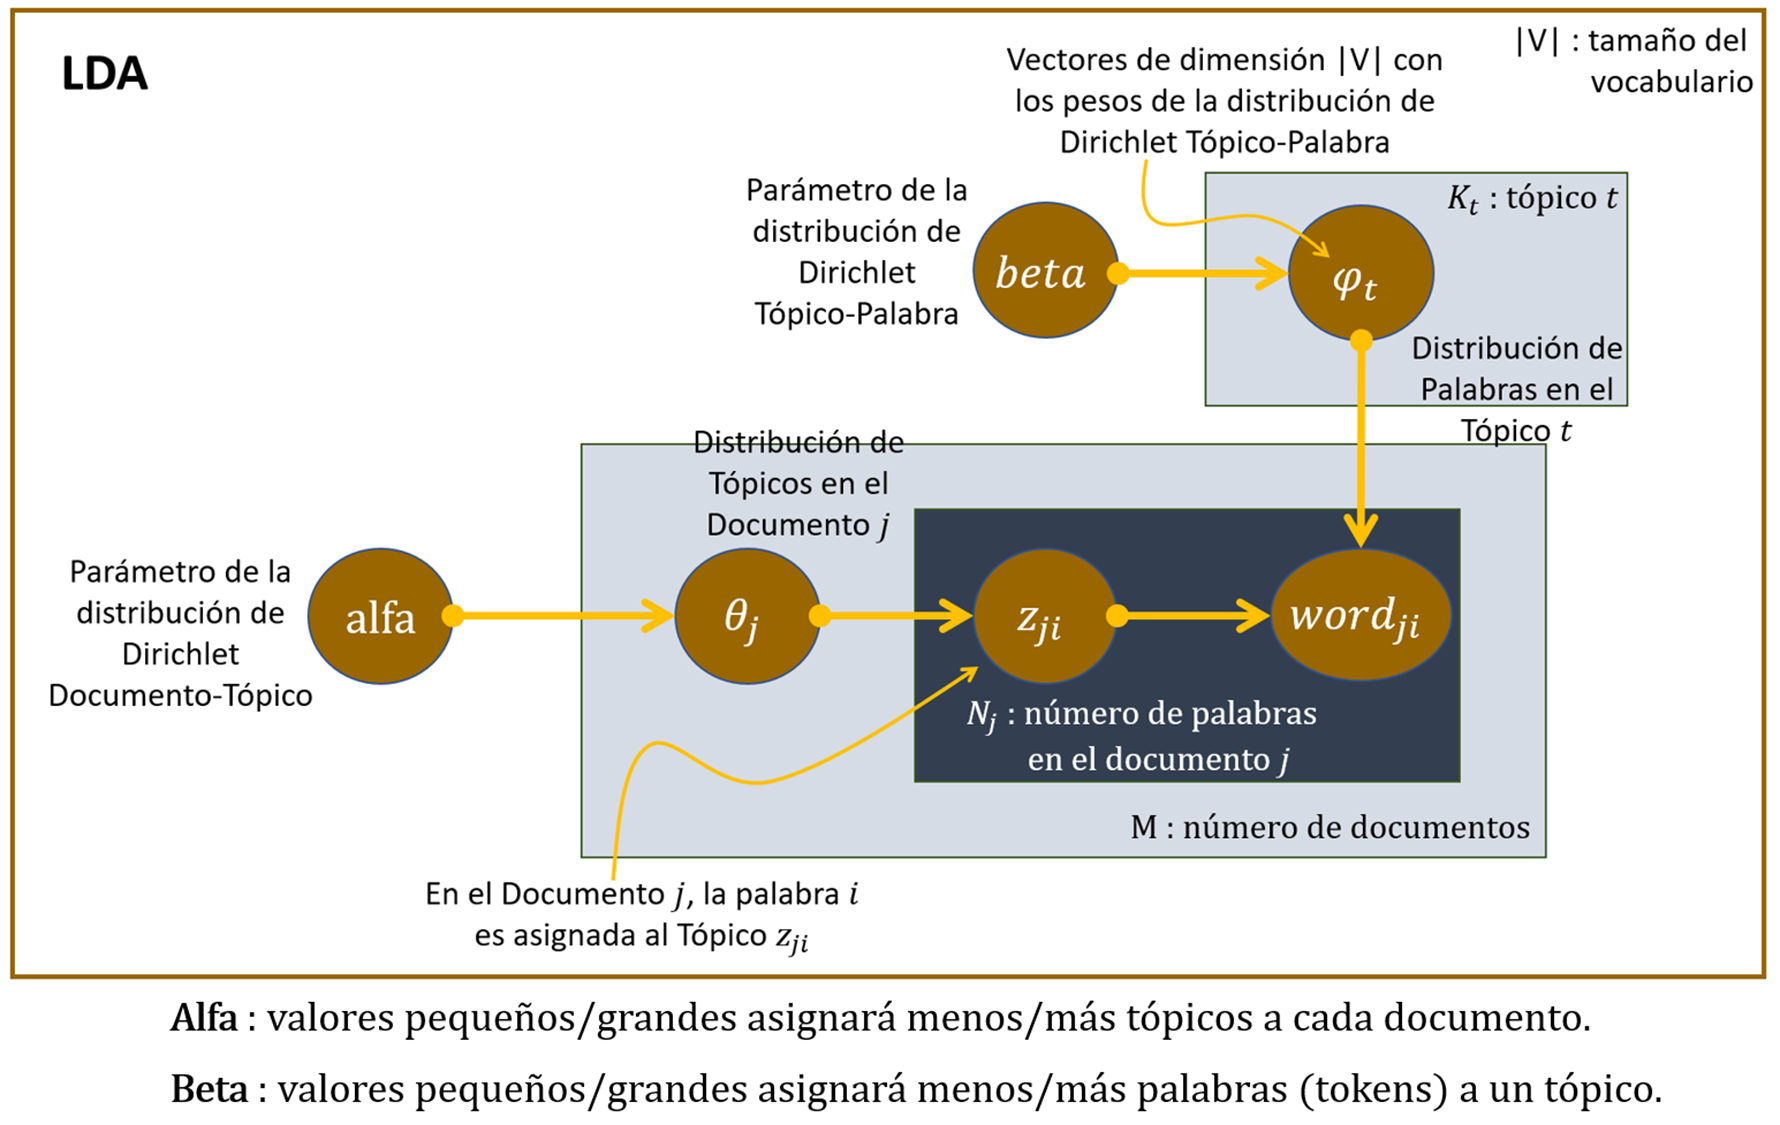 

Matemáticamente dicho algoritmo LDA ilustrado arriba se puede escribir como sigue: 

### $P(W,Z,θ,ϕ; α, β)= Π_{j=1}^{M} P(θ_{j}; α) Π_{t=1}^{K} P(ϕ_{t};β) \Pi_{i=1}^{N}P(Z_{j,i}|θ_{j})P(W_{j,i}|ϕ_{t}z_{j,i})$

Los dos hiperparámetros del método LDA que controlan la similaridad entre documentos, tópicos y palabras, son alfa y beta.

Mientras más palabras tengan los tópicos, mayor similaridad podrá existir entre ellos.

Así, mientras más pequeño es el alfa, “más enfocados” estarán los documentos en ciertos temas.

De manera análoga, mientras más pequeño es beta, “más enfocado” estará cada tópico. Es decir, cada tópico estará formado por el conjunto de palabras de todo el vobcabulario, donde a cada palabra le asigna una probabilidad. Cuando beta es pequeña, solo unas cuantas palabras tendrán una probabilidad grande, que serán las que definan el tópico en sí, y el resto tendrá valores muy cercanos a cero. 

Observa que cada tópico no es entonces simplemente un conjunto de palabras, sino un conjunto de palabras con una función distribución de probabilidad.

En este ejemplo sencillo usaremos el modelo de Gensim llamado LdaModel, pero para documentos grandes conviene utilizar la opción paralelizable LdaMulticore:

https://radimrehurek.com/gensim/models/ldamodel.html 

https://radimrehurek.com/gensim/models/ldamulticore.html

Continuemos en el corpus ya tokenizado y simplificado que definimos inicialmente:

In [288]:
docs

[['manzana', 'manzana', 'pera', 'pera', 'uva', 'uva', 'melon', 'sandia'],
 ['manzana', 'manzana', 'manzana', 'uva', 'uva', 'melon', 'melon', 'cocina'],
 ['estufa', 'estufa', 'estufa', 'olla', 'olla', 'olla', 'horno', 'horno'],
 ['horno', 'horno', 'horno', 'cuchara', 'cuchara', 'olla', 'uva', 'uva'],
 ['horno', 'manzana', 'pera', 'pera', 'olla', 'olla'],
 ['libro', 'libro', 'autor', 'novela', 'novela', 'ficcion']]

## 📖 Diccionario para LDA
Mismo proceso que para LSI con Gensim: crear el mapeo `palabra → ID`. La impresión muestra los primeros 7 IDs con sus palabras correspondientes.

In [289]:
# generamos el diccionario:

id2word = corpora.Dictionary(docs)

for id in range(7):
    print(id2word[id])

manzana
melon
pera
sandia
uva
cocina
estufa


## 🗃️ Corpus en formato BOW para LDA
Cada documento se convierte a lista de tuplas `(índice, frecuencia)`. Este formato es el que entiende `LdaModel`. El corpus completo es una lista de estas listas.

In [290]:
# Generamos el corpus con las tuplas (índice, frecuencia):

corpus = [id2word.doc2bow(doc) for doc in docs]
corpus

[[(0, 2), (1, 1), (2, 2), (3, 1), (4, 2)],
 [(0, 3), (1, 2), (4, 2), (5, 1)],
 [(6, 3), (7, 2), (8, 3)],
 [(4, 2), (7, 3), (8, 1), (9, 2)],
 [(0, 1), (2, 2), (7, 1), (8, 2)],
 [(10, 1), (11, 1), (12, 2), (13, 2)]]

## 🔓 Decodificar el BOW (solo para verificar)
Convierte los IDs numéricos de vuelta a palabras para confirmar que la representación BOW es correcta. Solo útil para depuración; no afecta el modelo.

In [291]:
# Siempre podemos expresar cada documento con palabras para un mejor entendimiento:
[[(id2word[id], fre) for id, fre in cor] for cor in corpus[:2]]

[[('manzana', 2), ('melon', 1), ('pera', 2), ('sandia', 1), ('uva', 2)],
 [('manzana', 3), ('melon', 2), ('uva', 2), ('cocina', 1)]]

## 🤖 Entrenamiento del modelo LDA
LDA asume que cada **documento** es una mezcla de temas (θ) y cada **tema** es una distribución de palabras (φ).

**Hiperparámetros clave:**
| Parámetro | Valor | Efecto |
|-----------|-------|--------|
| `num_topics` | 4 | Cuántos temas buscar |
| `passes` | 10 | Iteraciones sobre el corpus completo |
| `alpha` | 0.2 | Bajo → cada doc se enfoca en pocos temas |
| `eta` | 0.2 | Bajo → cada tema definido por pocas palabras |

Con `alpha` y `eta` bajos los temas son más "puros" y específicos.

## 📥 Datos de entrada — Parte 3 (LDA)

LDA usa **su propio diccionario y corpus**, creados justo arriba con `id2word` y `corpus`. Aunque parten de los mismos `docs`, son objetos nuevos independientes del `mi_dicc` y `bow` de la Parte 2.

**¿Por qué recrearlos?** Buena práctica: cada modelo tiene su propio diccionario para evitar dependencias cruzadas. En un pipeline real los compartirías.

In [292]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                    id2word=id2word,
                    num_topics=4,      # total de tópicos que deseas buscar...
                    chunksize=5,    # número de documentos a analizar en cada chunk de entrenamiento
                    passes=10,        # número de pasadas al corpus durante el entrenamiento.
                    alpha=0.2,        # alfa: similaridad document-topics
                    eta=0.2,         # beta: similaridad topic-words      
                    )

## 🎛️ Parámetros ajustables — LDA

| Parámetro | Valor actual | Criterio para cambiarlo |
|-----------|-------------|------------------------|
| `num_topics=4` | 4 temas | El más importante. Usa la Coherencia (Parte 5) para encontrar el óptimo. Aquí se usa 4 aunque sabemos que son 3, porque produce mejor separación |
| `chunksize=5` | 5 docs/lote | En corpus grandes: 1000-2000. Aquí igualado al corpus (6 docs) |
| `passes=10` | 10 pasadas | Súbelo a 20-50 si la coherencia no converge entre corridas |
| `alpha=0.2` | Bajo | **Bajo** → cada doc se enfoca en pocos temas. **Alto** (ej. 1.0) → cada doc mezcla muchos temas |
| `eta=0.2` | Bajo | **Bajo** → cada tema definido por pocas palabras. **Alto** → temas difusos con muchas palabras |

⚠️ **Regla práctica:** empieza con `alpha=0.1` y `eta=0.1` para temas puros. Sube si los temas se mezclan demasiado.

## 🏷️ Temas descubiertos por LDA
A diferencia de LSI, LDA devuelve **probabilidades** (siempre positivas, suman ~1 por tema). La interpretación es directa: `0.303*"novela"` significa que "novela" tiene 30.3% de probabilidad dentro de ese tema.

In [293]:
lda_model.print_topics(num_topics=4, num_words=4)

[(0, '0.206*"horno" + 0.206*"olla" + 0.141*"pera" + 0.110*"estufa"'),
 (1, '0.303*"novela" + 0.303*"libro" + 0.156*"autor" + 0.156*"ficcion"'),
 (2, '0.288*"manzana" + 0.217*"uva" + 0.185*"melon" + 0.077*"cocina"'),
 (3, '0.071*"sandia" + 0.071*"manzana" + 0.071*"ficcion" + 0.071*"autor"')]

En este caso sencillo, aunque sabemos que el número de tópicos son 3 estrictamente, con 4 tópicos es como se observan mejor las tres distribuciones tópicos-palabras. Es decir, sigue siendo requerida la inspección visual y criterio del analista para tomar la mejor decisión sobre la mejor cantidad de tópicos o conceptos latentes.

# Parte - 4: Predicción de datos nuevos

Una vez generado el modelo no supervisado LDA, supongamos que tenemos un nuevo documento del cual desramo saber a cuál tópico pertence. Veamos cómo proceder:

## 🆕 Parte 4 — Predicción: ¿a qué tema pertenece un texto nuevo?

**Contexto:** el modelo LDA ya está entrenado con los 6 documentos de frutas/cocina/literatura.
Ahora simulamos que llega un texto nuevo y queremos saber automáticamente a qué tema pertenece.

**Flujo de esta parte:**
```
dato_nuevo (lista de tokens)
    ↓  id2word.doc2bow()     → convertir al mismo formato BOW del entrenamiento
    ↓  lda_model[bow_nuevo]  → el modelo devuelve probabilidades por tema
    ↓  DataFrame + gráfica   → visualizar qué tema domina
    ↓  lda_model.show_topic()→ ver las palabras de cada tema
```

📥 **Datos de entrada:** `lda_model` (entrenado en Parte 3) + `id2word` (diccionario de Parte 3) + `dato_nuevo` (texto que defines tú).

## 📥 Dato de entrada — documento nuevo para predicción

`dato_nuevo` es el único parámetro que cambiarías en producción. Debe ser una lista de tokens **ya limpios** (sin stopwords, lematizados), igual que los documentos de entrenamiento.

🎛️ **Cámbialo por cualquier texto de tu dominio:**
```python
dato_nuevo = ['cliente', 'reclamo', 'cargo', 'cuenta']   # → tema bancario
dato_nuevo = ['python', 'error', 'instalacion', 'pip']    # → tema técnico
```

⚠️ Palabras que no estaban en el vocabulario de entrenamiento se ignoran automáticamente (`id2word.doc2bow` las descarta).

In [294]:
dato_nuevo = ['uva', 'libro','autor','ficción']

## 🔄 Convertir el nuevo documento a BOW

El documento nuevo debe pasar por el **mismo proceso** que los documentos de entrenamiento.

`id2word.doc2bow(dato_nuevo)` devuelve una lista de tuplas `(id_palabra, frecuencia)`.
La celda siguiente muestra esas tuplas — por ejemplo `[(4,1),(10,1),(12,1)]` significa:
- palabra con id 4 apareció 1 vez
- palabra con id 10 apareció 1 vez  
- palabra con id 12 apareció 1 vez

⚠️ `'ficción'` (con tilde) no estará en el vocabulario porque el corpus original tenía `'ficcion'` (sin tilde) — esa palabra se descarta silenciosamente.

In [296]:
# Generamos su representación en lista de tuplas (idx,frec):
bow_nuevo = id2word.doc2bow(dato_nuevo)   

# Indices de los topicos mas significativos
dist_indices = [topico[0] for topico in lda_model[bow_nuevo]]

# Contribucion de los topicos mas significativos
dist_contrib = [topico[1] for topico in lda_model[bow_nuevo]]

In [295]:
bow_nuevo

[(4, 1), (10, 1), (12, 1)]

## ⚠️ Límite crítico: LDA predice documentos, no palabras individuales

**Palabras fuera del vocabulario (OOV) se descartan silenciosamente.**

```python
dato_nuevo = ['teclado']   # 'teclado' no estaba en el corpus → bow_nuevo = []
dato_nuevo = ['piña']      # 'piña' es una fruta pero no estaba → bow_nuevo = []
```

Para LDA, `piña` y `teclado` son exactamente lo mismo: desconocidas.
El modelo no sabe que piña es una fruta porque **no entiende significado** — solo aprendió patrones de co-ocurrencia de las palabras que sí vio.

**Con bow vacío, LDA devuelve la distribución prior (alpha):**
```
Tópico 0 → ~0.25   ← no sabe nada, distribuye uniformemente
Tópico 1 → ~0.25
Tópico 2 → ~0.25
Tópico 3 → ~0.25
```

**LDA predice la mezcla de temas de un documento completo**, no el tema de cada palabra:
```python
# Funciona bien:
dato_nuevo = ['manzana','pera']      # → frutas
dato_nuevo = ['novela','autor']      # → literatura
dato_nuevo = ['manzana','novela']    # → mezcla frutas + literatura

# No aporta información:
dato_nuevo = ['piña']                # → distribución uniforme (OOV)
dato_nuevo = ['teclado','monitor']   # → distribución uniforme (OOV)
```

🔗 **¿Cómo lo resuelven los Embeddings (Semana 5)?**
Con Word2Vec/BERT, 'piña' estaría cerca de 'manzana' en el espacio semántico aunque nunca se haya visto en el corpus de entrenamiento. Esa es exactamente la limitación que motivó la evolución de BOW → Embeddings.

## 📊 Leer la distribución de temas del documento nuevo

`lda_model[bow_nuevo]` devuelve una lista de tuplas `(id_tema, probabilidad)`.

La **probabilidad indica qué tan probable es que el documento pertenezca a ese tema**.
La suma de todas las probabilidades es ≈ 1.0.

```
Tópico 1 → 0.75  ← tema dominante (Literatura: novela, libro, autor)
Tópico 2 → 0.15
Tópico 0 → 0.08
Tópico 3 → 0.02
```

La gráfica de barras muestra esto visualmente — la barra más alta es el tema asignado.
La celda siguiente imprime las palabras principales de cada tema para poder interpretarlo.

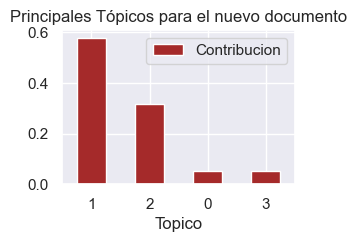

In [304]:
distribucion_topicos = pd.DataFrame({'Topico':dist_indices,
                                     'Contribucion':dist_contrib })

distribucion_topicos.sort_values('Contribucion', 
                                 ascending=False, inplace=True)

ax = distribucion_topicos.plot.bar(y='Contribucion',
                                   x='Topico', 
                                   rot=0, 
                                   color="brown",
                                   title = 'Principales Tópicos para el nuevo documento')

## 📏 Por qué el tamaño del corpus importa para las predicciones

Con 6 documentos y 14 palabras (este ejercicio), el modelo apenas tiene señal:
- Pocas co-ocurrencias → temas poco definidos
- Vocabulario pequeño → casi todo es OOV
- Coherencia baja (~0.25) → temas poco confiables

Con un corpus real (ej. un libro completo o miles de reseñas):
```
Capítulos 1-5:   rey, trono, espada, guerra → Tópico: Medieval
Capítulos 6-10:  amor, carta, corazón       → Tópico: Romance
Capítulos 11-15: veneno, traición, sombra   → Tópico: Intriga
```
Miles de co-ocurrencias reales → temas sólidos → predicción confiable.

| | 6 docs (ejercicio) | Libro / corpus real |
|--|-------------------|---------------------|
| Vocabulario | 14 palabras | Miles de palabras |
| Palabras OOV | Casi todo | Solo términos rarísimos |
| Coherencia | ~0.25 | >0.5 |
| Predicción | Mecánica, ilustrativa | Útil en producción |

**El ejercicio enseña la mecánica — el valor real aparece a escala.**

In [310]:
# Mostrar las palabras principales de cada tema y su clasificación

# top_n: cuántas palabras mostrar por tema para entender de qué trata
top_n = 4

# Para cada tema en orden de relevancia para este documento:
# 1. Imprime el número del tema
# 2. Muestra sus top_n palabras más representativas
# Así puedes leer: "el documento pertenece principalmente al Tópico X, que habla de: novela, libro..."
for ind, topico in distribucion_topicos.iterrows():
    print("<Tópico: " + str(int(topico.Topico)) + ">")
    palabras = [palabra[0] for k,palabra in 
                enumerate(lda_model.show_topic(topicid=int(topico.Topico))) if k<top_n]
    palabras = ', '.join(palabras)
    print(palabras, "
")

<Tópico: 1>
novela, libro, autor, ficcion 

<Tópico: 2>
manzana, uva, melon, cocina 

<Tópico: 0>
horno, olla, pera, estufa 

<Tópico: 3>
sandia, manzana, autor, ficcion 



# Parte - 5: métrica de Coherencia

https://radimrehurek.com/gensim/models/coherencemodel.html 

coherence: c_uci, c_v

window_size: c_uci:10, c_v:110

topn: solamente se extraen las topn palabras de cada tópico

Matemáticamente existen formas diferentes de definir la coherencia, aparte de que cada librería introduce en ocasiones diversas variantes.

Sin embargo, en general lo que trata de medir esta métrica en cada tópico es la similaridad semántica entre las palabras que pondera probabilísticamente. 

Una de las formas usuales de definir esta métrica entre dos palabras $w_i$ y $w_j$ es de la forma siguiente:

$Coherencia_{UCI} = log{\frac{P(w_i,w_j)+1}{P(w_i)P(w_j)}}$

donde $P(w_i)$ es la probabilidad de ver dicha palabra en una ventana de longitud "window_size" y $P(w_i,w_j)$ es la probabilidad de que ambas palabras aparezcan en dicha ventana.

El valor entero "window_size" significa que la ventana de búsqueda se extiende a dicha cantidad de enteros, antes y después de una palabra central $w_i$.

Hay una definición más sencilla llamada usualmente $Coherencia_{UMASS}$ donde ahora considera la probabilidad de que aparezcan juntas dos palabras en un documento, con respecto a que una de ellas esté en dicho documento.

## 📐 Parte 5 — Coherencia: validar y elegir el mejor k para LDA

**¿Por qué esta parte existe?** En la Parte 3 elegimos `num_topics=4` manualmente.
La Parte 5 muestra cómo hacerlo de forma **objetiva y sistemática** usando la métrica de Coherencia.

**Orden lógico en un proyecto real:**
```
1. Primero correr Parte 5  → encontrar el k con mayor coherencia
2. Luego usar ese k en Parte 3 → entrenar el modelo definitivo
```
En el notebook está al revés por motivos pedagógicos (se ve el modelo antes de la métrica).

📥 **Datos de entrada:** `lda_model` (Parte 3) + `docs` (corpus original) + `id2word` (diccionario Parte 3).

In [231]:
# Veamos la evaluación con el valor de la coherencia:

coherence_model_lda = CoherenceModel(model=lda_model, 
                                     texts=docs, 
                                     dictionary=id2word, 
                                     coherence='c_v',
                                     window_size=2,
                                     topn=5
                                     )

coherence_lda = coherence_model_lda.get_coherence()

print('Coherencia: ', coherence_lda)

Coherencia:  0.45489843250943296


## 🎯 Coherencia ≠ Calidad de predicción — distinción crítica

La coherencia **NO** mide si el modelo predice correctamente. Mide:
> ¿Las palabras que el modelo agrupó en un tema tienen sentido semántico juntas?

```
Tema A: manzana, pera, uva, melón    → coherencia ALTA ✅ co-ocurren naturalmente
Tema B: manzana, horno, novela, uva  → coherencia BAJA ❌ mezcla sin sentido
```

**Comparación con métricas supervisadas:**

| Métrica | Qué mide | Cuándo usarla |
|---------|----------|---------------|
| Accuracy / F1 | Si predijo la etiqueta correcta | Supervisado (Naive Bayes, SVM...) |
| **Coherencia** | Si los temas tienen sentido semántico | **No supervisado (LDA, LSI)** |

**Lo que la coherencia SÍ te dice:**
- Cuál k produce temas más interpretables
- Si el modelo encontró estructura real o ruido

**Lo que NO te dice:**
- Si la predicción de un documento nuevo es correcta
- Si el tema asignado es el "verdadero" (no existe esa verdad sin etiquetas)

En resumen: la coherencia valida la **calidad del modelo**, no la **precisión de cada predicción**. Es la única métrica de evaluación disponible cuando no tienes etiquetas.

## 🔧 Función para barrer múltiples valores de k
Automatiza el entrenamiento de un LDA por cada valor de `num_topics` desde `start` hasta `limit` con saltos de `step`. Devuelve la lista de modelos y sus coherencias para graficar la curva y elegir el mejor k.

In [242]:
def valores_de_coherencia(dictionary, corpus, texts, limit, start, step):

    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
      model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                    id2word=id2word,
                    num_topics=num_topics,      # total de tópicos que deseas buscar...
                    chunksize=6,    # número de documentos a analizar en cada chunk de entrenamiento
                    passes=10,        # número de pasadas al corpus durante el entrenamiento.
                    alpha=0.1,        # alfa: similaridad document-topics
                    eta=0.15,         # beta: similaridad topic-words  
                    random_state=7
                    )
    
    
      model_list.append(model)

        
      coherencemodel = CoherenceModel(model=model, 
                                      texts=texts, 
                                      dictionary=dictionary, 
                                      coherence='c_v',
                                      window_size=2,
                                      topn=3)
    
      coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

## ▶️ Ejecutar la búsqueda de k óptimo
Se prueba de k=2 a k=9. La gráfica de coherencia vs número de temas muestra en qué punto sube o se estabiliza — ese es el k recomendado.

## 🎛️ Parámetros ajustables — Función de Coherencia

| Parámetro | Valor actual | Criterio |
|-----------|-------------|----------|
| `start=2` | Mínimo 2 temas | Siempre empieza en 2; 1 tema no tiene sentido para topic modeling |
| `limit=10` | Hasta k=9 | Amplía si el corpus es rico. Con 6 docs no tiene sentido ir más allá de 8 |
| `step=1` | Evalúa cada k | Usa `step=2` para exploración rápida en corpus grandes |

📥 **Datos de entrada:** `id2word`, `corpus` y `docs` — todos definidos en la Parte 3 (LDA). La función reutiliza estos objetos directamente.

In [243]:
start=2
limit=10
step=1

model_list, coherence_values = valores_de_coherencia(dictionary=id2word, 
                                                        corpus=corpus, 
                                                        texts=docs, 
                                                        start=start, 
                                                        limit=limit, 
                                                        step=step)

## 📈 Gráfica de Coherencia vs Número de Temas

El pico o codo de esta curva indica el k recomendado.

**Para acceder a un modelo específico de la lista:**
```python
# La lista empieza en start=2, entonces:
# model_list[0] → modelo con k=2
# model_list[1] → modelo con k=3   ← lo que usa la celda siguiente
# model_list[2] → modelo con k=4
# Fórmula general: model_list[k - start]
```

La celda `model_list[1].print_topics()` muestra el modelo con **k=3**, que en este corpus es donde los temas quedan mejor separados (frutas / cocina / literatura).

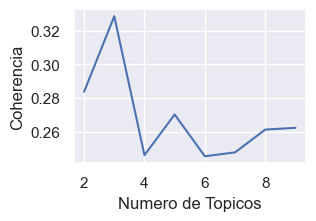

In [244]:
x = range(start, limit, step)

plt.plot(x, coherence_values)
plt.xlabel("Numero de Topicos")
plt.ylabel("Coherencia")
plt.show()

In [248]:
model_list[1].print_topics(num_words=4)

[(0, '0.153*"uva" + 0.153*"olla" + 0.153*"horno" + 0.153*"manzana"'),
 (1, '0.071*"horno" + 0.071*"manzana" + 0.071*"pera" + 0.071*"olla"'),
 (2, '0.265*"libro" + 0.265*"novela" + 0.142*"ficcion" + 0.142*"autor"')]

Como comentamos previamente, en ocasiones la métrica de coherencia nos lleva al teóricamente cantidad de tópicos correctos, pero no a la mejor distribución de las palabras en cada tópico.

# Parte - 6: BIGRAMAS y TRIGRAMAS

Recordemos que un "n-grama" es una cadena de "n" caracteres cuya frecuencia es suficientemente alta, como para empezar a considerarlo como un solo token.

En particular, nombres de personas, instituciones, ciudades o productos son ejemplos típicos de "n-gramas".

Los "n-gramas" enriquecen en gran medida el sisgnificado de los documentos, ya que la secuencia de dichos tokens tienen un significado muy diferente al que tiene cada uno de ellos por separado.

Cuando sabemos de antemano que estamos trabajando con ciertos "n-gramas", se pueden incluir desde un inicio como tales. Por ejemplo, Tecnológico de Monterrey, podría considerarse como un tri-grama y sustituir este conjunto de palabras por Tecnologico_de_Monterrey, o bien TecnologicoDeMonterrey, entre otras formas diferentes que pudieran considerarse.

En dado caso, si se incluyen guiones bajos como en este ejemplo para definir un "n-grama", deberás tomarlo en cuenta para que no se pierdan durante el proceso de limpieza. 

In [273]:
from gensim.models import Phrases

## 🔗 Parte 6 — Bigramas y Trigramas: cuándo y por qué usarlos

**¿Dónde encajan en el pipeline?**
```
Texto crudo
    ↓ tokenización + limpieza   (Semana 2)
    ↓ detección de n-gramas     ← AQUÍ va esta parte
    ↓ TF-IDF / BOW              (Partes 1-3)
    ↓ LSI / LDA                 (Partes 1-3)
```

Los bigramas/trigramas se detectan **antes** de construir el vocabulario para que términos como `Octavio_Paz` o `Ciudad_de_México` se traten como un solo token, no como palabras separadas.

⚠️ **Cambio de corpus:** esta parte usa texto sobre Octavio Paz — diferente a `docs` (frutas/cocina). Se hace así porque para detectar bigramas se necesitan nombres propios o frases que se repitan varias veces.

📥 **Variables nuevas en esta parte:**

| Variable | Qué es |
|----------|--------|
| `texto` | Lista de 7 oraciones sobre Octavio Paz |
| `txt_token` | Cada oración dividida por espacios (split simple) |
| `bigramas` | Modelo que detecta pares de palabras frecuentes |
| `trigramas` | Modelo que detecta tríos (bigramas sobre bigramas) |

In [270]:
texto = [['Octavio Paz, fue un poeta, ensayista y diplomático mexicano.'], 
         ['Octavio Paz obtuvo el Premio Nobel de Literatura en 1990 y el Premio Cervantes en 1981.'],
         ['Se le considera uno de los más influyentes autores del siglo xx y uno de los más grandes poetas de todos los tiempos.'],
         ['Su padre fue Octavio Paz Solórzano y su madre Josefina Lozano.'],
         ['Octavio Paz nació en la Ciudad de México el 31 de marzo de 1914.'],
         ['Murió en la Ciudad de México el 19 de abril de 1998.'],
         ['De pequeño vivió con su abuelo en Mixcoac, en ese entonces un poblado cercano a la Ciudad de México.']
        ]

txt_token = [txt[0].split(' ') for txt in texto]


print(txt_token[0:2])

[['Octavio', 'Paz,', 'fue', 'un', 'poeta,', 'ensayista', 'y', 'diplomático', 'mexicano.'], ['Octavio', 'Paz', 'obtuvo', 'el', 'Premio', 'Nobel', 'de', 'Literatura', 'en', '1990', 'y', 'el', 'Premio', 'Cervantes', 'en', '1981.']]


## 🔗 Detección automática de Bigramas
`Phrases` detecta pares de palabras que co-ocurren con frecuencia suficiente para tratarse como un solo token.

| Parámetro | Significado |
|-----------|-------------|
| `min_count=2` | La pareja debe aparecer ≥2 veces en el corpus |
| `threshold=10` | Umbral de puntuación mínima (mayor = más estricto) |

**Resultado:** `Octavio Paz` → `Octavio_Paz`, `la Ciudad` → `la_Ciudad`. El guion bajo une las palabras del bigrama.

## 🔗 Conexión con Semana 2: Regex vs Phrases — misma idea, distinta ejecución

En Semana 2 ya hiciste esto con Regex de forma **manual**:
```python
# Semana 2 — tú decidías qué frases unir:
re.sub(r'New York', 'New_York', texto)
re.sub(r'machine learning', 'machine_learning', texto)
```

`Phrases` de Gensim hace lo mismo pero de forma **automática**, descubriendo qué pares son frecuentes:
```python
# Semana 6-7 — el algoritmo descubre las frases solo:
bigramas = Phrases(txt_token, min_count=2, threshold=10)
# detecta que 'Octavio'+'Paz' → 'Octavio_Paz'
```

| | Regex (Semana 2) | Phrases (Semana 6-7) |
|--|-----------------|---------------------|
| Detección | Manual — tú listas las frases | Automática — por frecuencia |
| Cuándo usarlo | Conoces los términos de tu dominio | Corpus grande, términos desconocidos |
| Ejemplo | 'Ciudad de México' → siempre igual | Detecta solo que 'Octavio Paz' es frecuente |

**En producción se usan los dos juntos:**
```
1. Regex primero  → términos críticos que ya conoces
2. Phrases después → captura los que no conocías
```
Es el mismo concepto: preservar el significado compuesto de frases multi-palabra.

In [271]:
# Búsqueda de bigramas:

bigramas = gensim.models.phrases.Phrases(txt_token, min_count=2, threshold=10)

for bb in bigramas[txt_token]:
    print(bb)

['Octavio', 'Paz,', 'fue', 'un', 'poeta,', 'ensayista', 'y', 'diplomático', 'mexicano.']
['Octavio_Paz', 'obtuvo', 'el', 'Premio', 'Nobel', 'de', 'Literatura', 'en', '1990', 'y', 'el', 'Premio', 'Cervantes', 'en', '1981.']
['Se', 'le', 'considera', 'uno', 'de', 'los', 'más', 'influyentes', 'autores', 'del', 'siglo', 'xx', 'y', 'uno', 'de', 'los', 'más', 'grandes', 'poetas', 'de', 'todos', 'los', 'tiempos.']
['Su', 'padre', 'fue', 'Octavio_Paz', 'Solórzano', 'y', 'su', 'madre', 'Josefina', 'Lozano.']
['Octavio_Paz', 'nació', 'en', 'la_Ciudad', 'de', 'México', 'el', '31', 'de', 'marzo', 'de', '1914.']
['Murió', 'en', 'la_Ciudad', 'de', 'México', 'el', '19', 'de', 'abril', 'de', '1998.']
['De', 'pequeño', 'vivió', 'con', 'su', 'abuelo', 'en', 'Mixcoac,', 'en', 'ese', 'entonces', 'un', 'poblado', 'cercano', 'a', 'la_Ciudad', 'de', 'México.']


## 🔗🔗 Trigramas = bigramas aplicados sobre texto que ya tiene bigramas

**Truco:** Gensim no tiene una clase "Trigrams" — los trigramas se crean aplicando Phrases dos veces:

```
txt_token original:          ['Octavio', 'Paz', 'nació', 'en', 'la', 'Ciudad', 'de', 'México']
    ↓ bigramas[txt_token]    ['Octavio_Paz', 'nació', 'en', 'la_Ciudad', 'de', 'México']
    ↓ trigramas[bigramas[]]  ['Octavio_Paz', 'nació', 'en', 'la_Ciudad_de', 'México']
```

`la_Ciudad_de` es un trigrama porque `la_Ciudad` (bigrama) + `de` co-ocurren suficientemente juntos.

In [ ]:
# Búsqueda de Trigramas: bigramas aplicados sobre el corpus que ya tiene bigramas
trigramas = gensim.models.phrases.Phrases(bigramas[txt_token], min_count=2, threshold=10)

In [272]:
# Búsqueda de Trigramas como la búsqueda de bigramas dentro de un corpus que ya incluye bigramas:

for k in range(len(txt_token)):
    print(trigramas[bigramas[txt_token[k]]])

['Octavio', 'Paz,', 'fue', 'un', 'poeta,', 'ensayista', 'y', 'diplomático', 'mexicano.']
['Octavio_Paz', 'obtuvo', 'el', 'Premio', 'Nobel', 'de', 'Literatura', 'en', '1990', 'y', 'el', 'Premio', 'Cervantes', 'en', '1981.']
['Se', 'le', 'considera', 'uno', 'de', 'los', 'más', 'influyentes', 'autores', 'del', 'siglo', 'xx', 'y', 'uno', 'de', 'los', 'más', 'grandes', 'poetas', 'de', 'todos', 'los', 'tiempos.']
['Su', 'padre', 'fue', 'Octavio_Paz', 'Solórzano', 'y', 'su', 'madre', 'Josefina', 'Lozano.']
['Octavio_Paz', 'nació', 'en', 'la_Ciudad_de', 'México', 'el', '31', 'de', 'marzo', 'de', '1914.']
['Murió', 'en', 'la_Ciudad_de', 'México', 'el', '19', 'de', 'abril', 'de', '1998.']
['De', 'pequeño', 'vivió', 'con', 'su', 'abuelo', 'en', 'Mixcoac,', 'en', 'ese', 'entonces', 'un', 'poblado', 'cercano', 'a', 'la_Ciudad_de', 'México.']


De esta manera se podría continuar la búsqueda de tetra-gramas y mayores, pero generalmente es incluirlos de manera directa con base al conocimiento de tus documentos, como se mención previamente.

La cantidad de "n-gramas" va disminuyendo a medida que se incrementa el valor de "n".

## Fin de los ejercicios complementarios de las semanas 6 y 7.